In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import viridis, jet, RdYlGn_r
from netCDF4 import Dataset as NetCDFFile
import netCDF4 as nc
import pandas as pd
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cf

import os

In [2]:
def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx

def normalize_array(data):
    vmax = np.amax(data)
    vmin = np.min(data)
    range_data = vmax - vmin
    
    normalized_data = (data - vmin)/range_data
    
    return normalized_data

def unnormalise(data_sr, data_lr):
    max = np.max(data_lr)
    min = np.min(data_lr)
    data_sr = data_sr * (max - min) + min
    return data_sr

## Past downstream task test (PS detection)

In [5]:
file = NetCDFFile('../RDS/OCO-2/oco2_GEOS_L3CO2_day_20200511_B10206Ar.nc4')
data = np.squeeze(file.variables['XCO2'][:])
lat = np.squeeze(file.variables['lat'][:])
lon = np.squeeze(file.variables['lon'][:])

lon_reshaped = np.reshape(lon, (1, 576))
lat_reshaped = np.reshape(lat, (361, 1))

new_lon, new_lat = np.broadcast_arrays(lon_reshaped, lat_reshaped)
new_lon = new_lon.flatten()
new_lat = new_lat.flatten()

In [6]:
lonE = 14
lonW = -6
latS = 42
latN = 60

print(0.5*31, 0.625*31)

extents = (lonW, lonW+19.375, latS, latS+15.5)

15.5 19.375


In [7]:
lonE_sr = find_nearest(lon, lonW+20)
lonW_sr = find_nearest(lon, lonW)
latS_sr = find_nearest(lat, latS)
latN_sr = find_nearest(lat, latS+16)

print(lonE_sr, lonW_sr, latS_sr, latN_sr)

310 278 264 296


In [6]:
europe_lr = np.load('Input/XCO2/europe_lr_2020.npy')
europe_lr = europe_lr*1e6
# europe_lr = data[latS_sr:latN_sr, lonW_sr:lonE_sr]
# np.save('europe_lr.npy', np.asarray(europe_lr))

In [7]:
print(np.shape(europe_lr))

(32, 32)


In [8]:
europe_sr = np.load('Result/XCO2/europe_lr_2020.npy')
europe_sr = unnormalise(europe_sr, europe_lr)


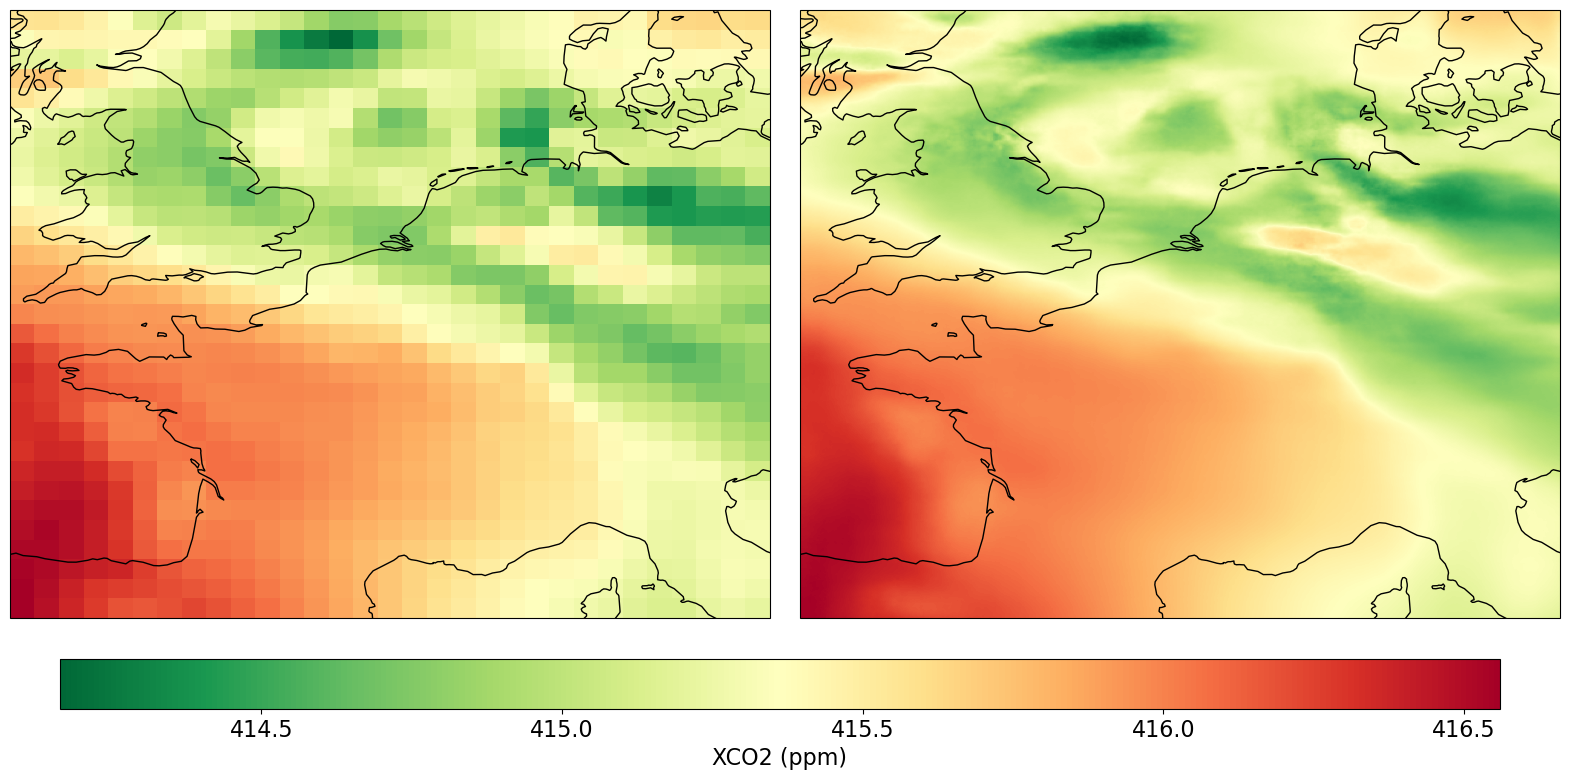

In [9]:
fig = plt.figure(figsize=(20, 10))
ax1 = fig.add_subplot(1, 2, 1, projection=ccrs.PlateCarree())
ax1.coastlines()
im = ax1.imshow(europe_lr[:-1,:-1], extent=extents, cmap=RdYlGn_r, vmin=np.min(europe_lr[:-1,:-1]), vmax=np.max(europe_lr[:-1,:-1]))
ax2 = fig.add_subplot(1, 2, 2, projection=ccrs.PlateCarree())
ax2.coastlines()
ax2.imshow(europe_sr[:-16,:-16], extent=extents, cmap=RdYlGn_r)
fig.subplots_adjust(wspace=0.04)
cbar_ax = fig.add_axes([0.15, 0.10, 0.72, 0.05])
cbar = fig.colorbar(im, orientation='horizontal', cax=cbar_ax)
cbar.ax.tick_params(labelsize=16)
cbar.set_label(label='XCO2 (ppm)', size=16)

-2.322456566616893e-06 2.0564802980516106e-06


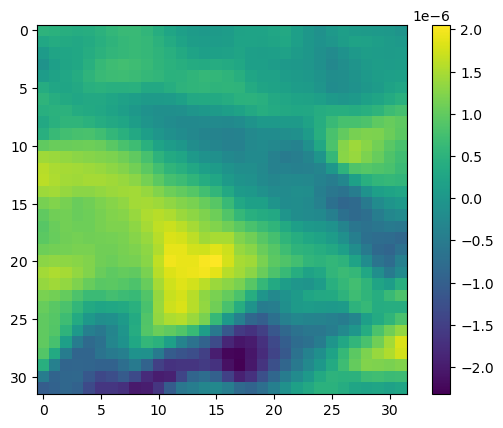

In [37]:
file_test = np.load('Input/XCO2/0_lr.npy')
file_lr = np.expand_dims(file_test, axis=0)
print(np.min(file_test), np.max(file_test))
plt.imshow(file_test)
plt.colorbar()


In [3]:
def normalize(data):
    return (data - np.min(data)) / (np.max(data) - np.min(data))

In [4]:
def unnormalize(array_sr, array_lr):
    for i in range(len(array_sr)):
        array_sr[i] = normalize(array_sr[i])
        min = np.min(array_lr[i])
        max = np.max(array_lr[i])
        array_sr[i] = (array_sr[i] * (max - min)) + min
    return array_sr

-3.0314077e-06 7.237941e-07


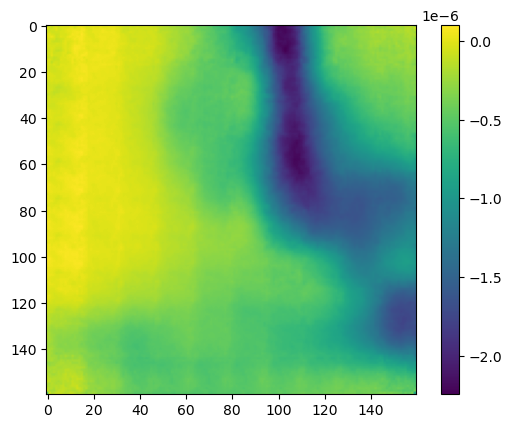

In [7]:
file_test = np.load('../../RDS/ephemeral/difference_xco2_test/sr/diff/0_lr.npy')
# file_test = np.transpose(file_test, (0, 2, 1))
file_test = unnormalize(file_test, lr)
print(np.min(file_test[0]), np.max(file_test[0]))
plt.imshow(file_test[1])
plt.colorbar()


(313, 10, 10)
-3.0314076866488904e-06 7.237940735648775e-07


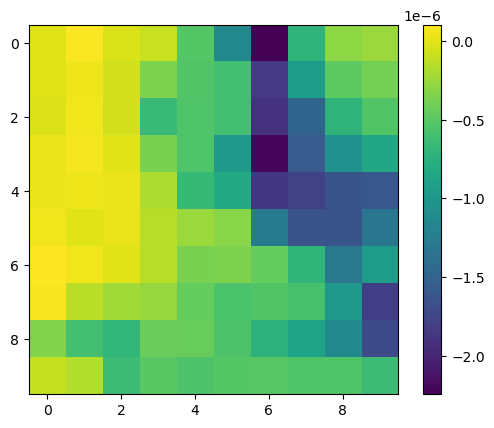

In [6]:
file_test = np.load('../../RDS/ephemeral/difference_xco2_test/lr/diff/0_lr.npy')
# print(np.min(file_test[0]))
print(file_test.shape)
print(np.min(file_test[0]), np.max(file_test[0]))
lr = file_test
plt.imshow(file_test[1])
plt.colorbar()


-2.2608513e-06 2.1352234e-06


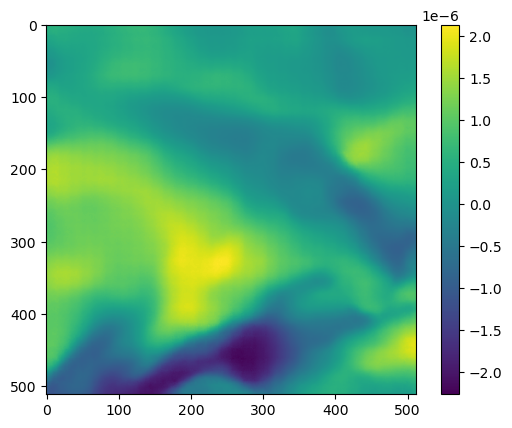

In [36]:
file_test = np.load('../../RDS/dbpn/DBPN_2/Result/XCO2/0_lr.npy')
file_test = unnormalize(np.expand_dims(file_test, axis=0), file_lr)
print(np.min(file_test), np.max(file_test))
plt.imshow(file_test[0])
plt.colorbar()

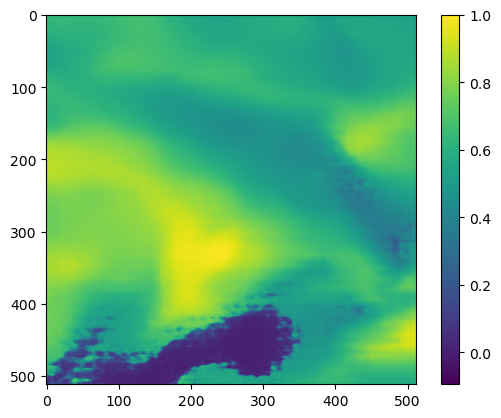

In [4]:
file_test = np.load('Result/XCO2/0_lr_old.npy')
plt.imshow(file_test)
plt.colorbar()

array([0., 1.])

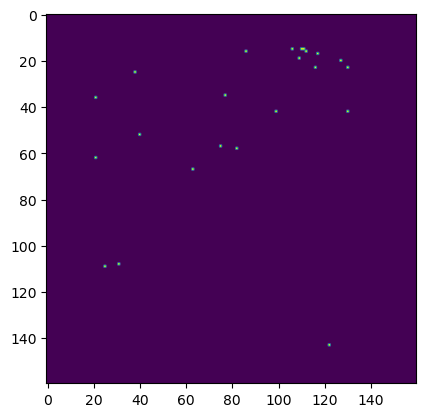

In [2]:
label_sr = np.load('../../RDS/ephemeral/difference_xco2_train/sr/labels/0_sr.npy')
plt.imshow(label_sr)

np.unique(label_sr)

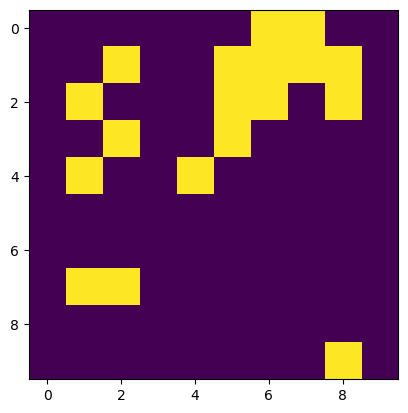

In [3]:
label_lr = np.load('../../RDS/ephemeral/difference_xco2_train/lr/labels/0_lr.npy')
plt.imshow(label_lr)

##  Bicubic interpolation

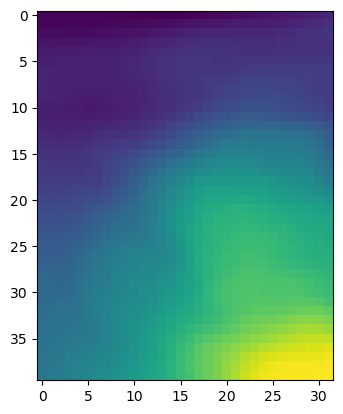

In [154]:
test = np.load('../../RDS/OCO-2/centered_arrays/ae20120522_20181031_20150103_lr.npy')
plt.imshow(test)

In [14]:
from scipy.interpolate import RegularGridInterpolator

In [37]:
europe_lr.shape

(32, 32)

In [15]:
x  = np.arange(0, 32)
y  = np.arange(0, 32)
europe_bicubic = RegularGridInterpolator((x, y), europe_lr, method='cubic')

In [16]:
# best_lat = 8
# best_lon = 10
x_sr = np.arange(0, 31, 1/16)
y_sr = np.arange(0, 31, 1/16)
xv, yv = np.meshgrid(x_sr, y_sr)
xv = xv.flatten()
yv = yv.flatten()
values = np.concatenate((xv[:, np.newaxis], yv[:, np.newaxis]), axis=1)
# values = np.array([best_lat, best_lon])
bic_europe = europe_bicubic(values)
print(bic_europe.shape)
# bic_europe = np.reshape(bic_europe, (16*15, 16*19))
# print(bic_europe)
# bic_europe = np.reshape(bic_europe, (3, 3))
# plt.imshow(bic_europe)

(246016,)


In [17]:
bic_europe = np.reshape(bic_europe, (16*31, 16*31))
bic_europe = np.transpose(bic_europe)

# plt.imshow(bic_europe)

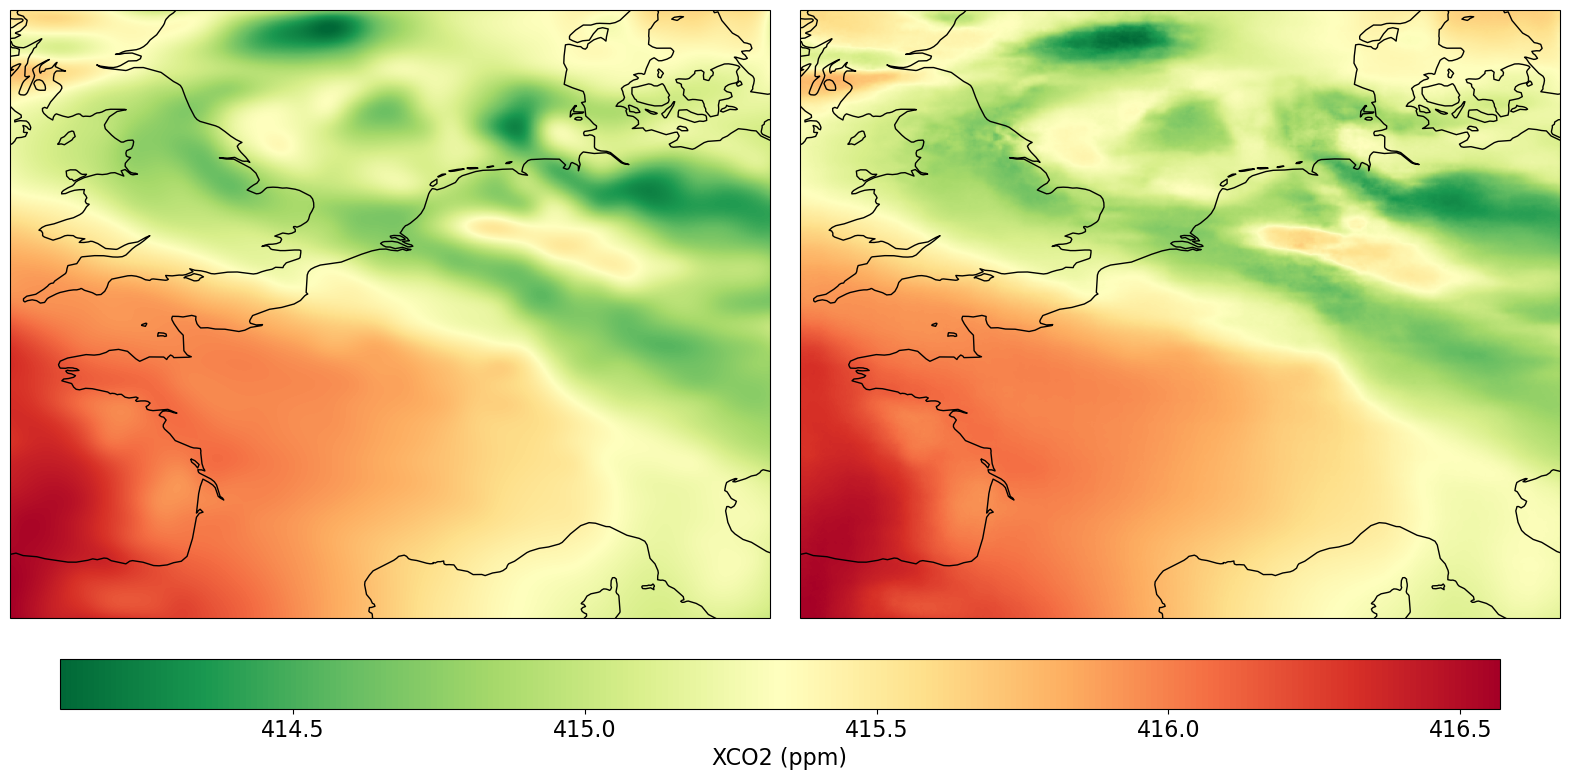

In [38]:
fig = plt.figure(figsize=(20, 10))
ax1 = fig.add_subplot(1, 2, 1, projection=ccrs.PlateCarree())
ax1.coastlines()
plt.imshow(bic_europe,extent=extents, cmap=RdYlGn_r, vmin=np.min(europe_lr[:-1,:-1]), vmax=np.max(europe_lr[:-1,:-1]))
ax2 = fig.add_subplot(1, 2, 2, projection=ccrs.PlateCarree())
ax2.coastlines()
im = ax2.imshow(europe_sr[:-16,:-16], extent=extents, cmap=RdYlGn_r)
fig.subplots_adjust(wspace=0.04)
cbar_ax = fig.add_axes([0.15, 0.10, 0.72, 0.05])
cbar = fig.colorbar(im, orientation='horizontal', cax=cbar_ax)
cbar.ax.tick_params(labelsize=16)
cbar.set_label(label='XCO2 (ppm)', size=16)

In [10]:
fusion_file = NetCDFFile('../../RDS/data_fusion/2020/2020-05-11.nc')
xco2 = np.asarray(fusion_file.variables['XCO2'][:])
Lat = np.asarray(fusion_file.variables['Lat'][:])
Lon = np.asarray(fusion_file.variables['Lon'][:])

lonE_f = find_nearest(Lon, lonW+20)
lonW_f = find_nearest(Lon, lonW)
latS_f = find_nearest(Lat, latS)
latN_f = find_nearest(Lat, latS+16)

print(lonE_f, lonW_f, latS_f, latN_f)

776 696 528 592


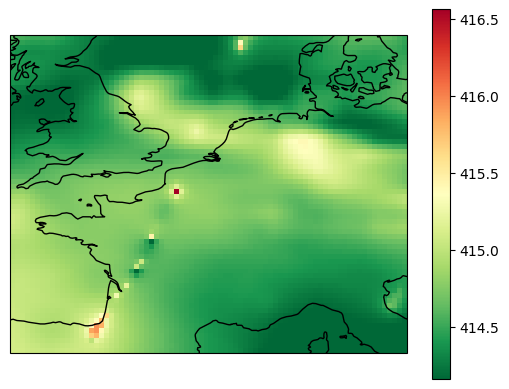

In [11]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.coastlines()
fus_europe = xco2[latS_f:latN_f, lonW_f:lonE_f]
plt.imshow(fus_europe, extent=extents, cmap=RdYlGn_r, vmin=np.min(europe_lr[:-1,:-1]), vmax=np.max(europe_lr[:-1,:-1]))
plt.colorbar()

In [12]:
minimum = min(np.min(europe_lr[:-1,:-1]), np.min(fus_europe))
maximum = max(np.max(europe_lr[:-1,:-1]), np.max(fus_europe))

print(minimum, maximum)

413.123 416.94464


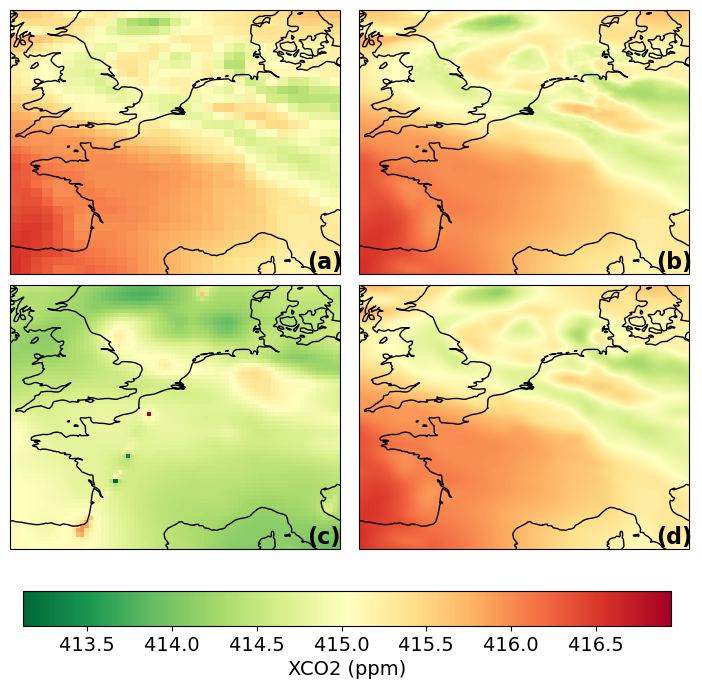

In [18]:
# sns.set()
subfigure_labels = ['(a)', '(b)', '(c)', '(d)']
fig = plt.figure()
ax1 = fig.add_subplot(2, 2, 1, projection=ccrs.PlateCarree())
ax1.text(0.9, 0, subfigure_labels[0], transform=ax1.transAxes, fontsize=16, fontweight='bold', va='bottom', ha='left')
ax1.coastlines()
im = ax1.imshow(europe_lr[:-1,:-1], extent=extents, cmap=RdYlGn_r, vmin=minimum, vmax=maximum)
ax2 = fig.add_subplot(2, 2, 2, projection=ccrs.PlateCarree())
ax2.text(0.9, 0, subfigure_labels[1], transform=ax2.transAxes, fontsize=16, fontweight='bold', va='bottom', ha='left')
ax2.coastlines()
ax2.imshow(europe_sr[:-16,:-16], extent=extents, cmap=RdYlGn_r, vmin=minimum, vmax=maximum)
ax3 = fig.add_subplot(2, 2, 3, projection=ccrs.PlateCarree())
ax3.text(0.9, 0, subfigure_labels[2], transform=ax3.transAxes, fontsize=16, fontweight='bold', va='bottom', ha='left')
ax3.coastlines()
ax3.imshow(fus_europe, extent=extents, cmap=RdYlGn_r, vmin=minimum, vmax=maximum)
ax4 = fig.add_subplot(2, 2, 4, projection=ccrs.PlateCarree())
ax4.text(0.9, 0, subfigure_labels[3], transform=ax4.transAxes, fontsize=16, fontweight='bold', va='bottom', ha='left')
ax4.coastlines()
ax4.imshow(bic_europe, extent=extents, cmap=RdYlGn_r, vmin=minimum, vmax=maximum)
fig.subplots_adjust(wspace=0, hspace=0.04)
cbar_ax = fig.add_axes([0.15, 0.0, 0.72, 0.05])
cbar = fig.colorbar(im, orientation='horizontal', cax=cbar_ax)
cbar.ax.tick_params(labelsize=14)
cbar.set_label(label='XCO2 (ppm)', size=14)
plt.s

## Land Surface Temperature data distribution VS CO2 data distribution

In [3]:
def normalize_array(data):
    vmax = np.amax(data)
    vmin = np.min(data)
    range_data = vmax - vmin
    
    normalized_data = (data - vmin)/range_data
    
    return normalized_data

def random_window(array, size=32):
    # print(array.shape)
    x = np.random.randint(0, array.shape[0]-size)
    y = np.random.randint(0, array.shape[1]-size)
    
    return array[x:x+size, y:y+size]

north_america_box = -135,10,-65.0,60
europe_box = -10, 40, 35, 70
africa_box = -20, -35, 50, 40
asia_box = 40, 0, 150, 70
south_america_box = -80, -50, -40, 10
oceania_box = 115, -40, 155, -10

def sample_within_coordinates(array, coordinates, lon, lat):
    lonW, latS, lonE, latN = coordinates
    lonW = find_nearest(lon, lonW)
    lonE = find_nearest(lon, lonE)
    latS = find_nearest(lat, latS)
    latN = find_nearest(lat, latN)

    if latS > latN:
        return random_window(array[latN:latS, lonW:lonE])
    else:
        return random_window(array[latS:latN, lonW:lonE])

def bin_values(array, bins=11):
    binned_array = np.digitize(array, np.linspace(0, 1, bins))
    
    return binned_array

NameError: name 'sns' is not defined

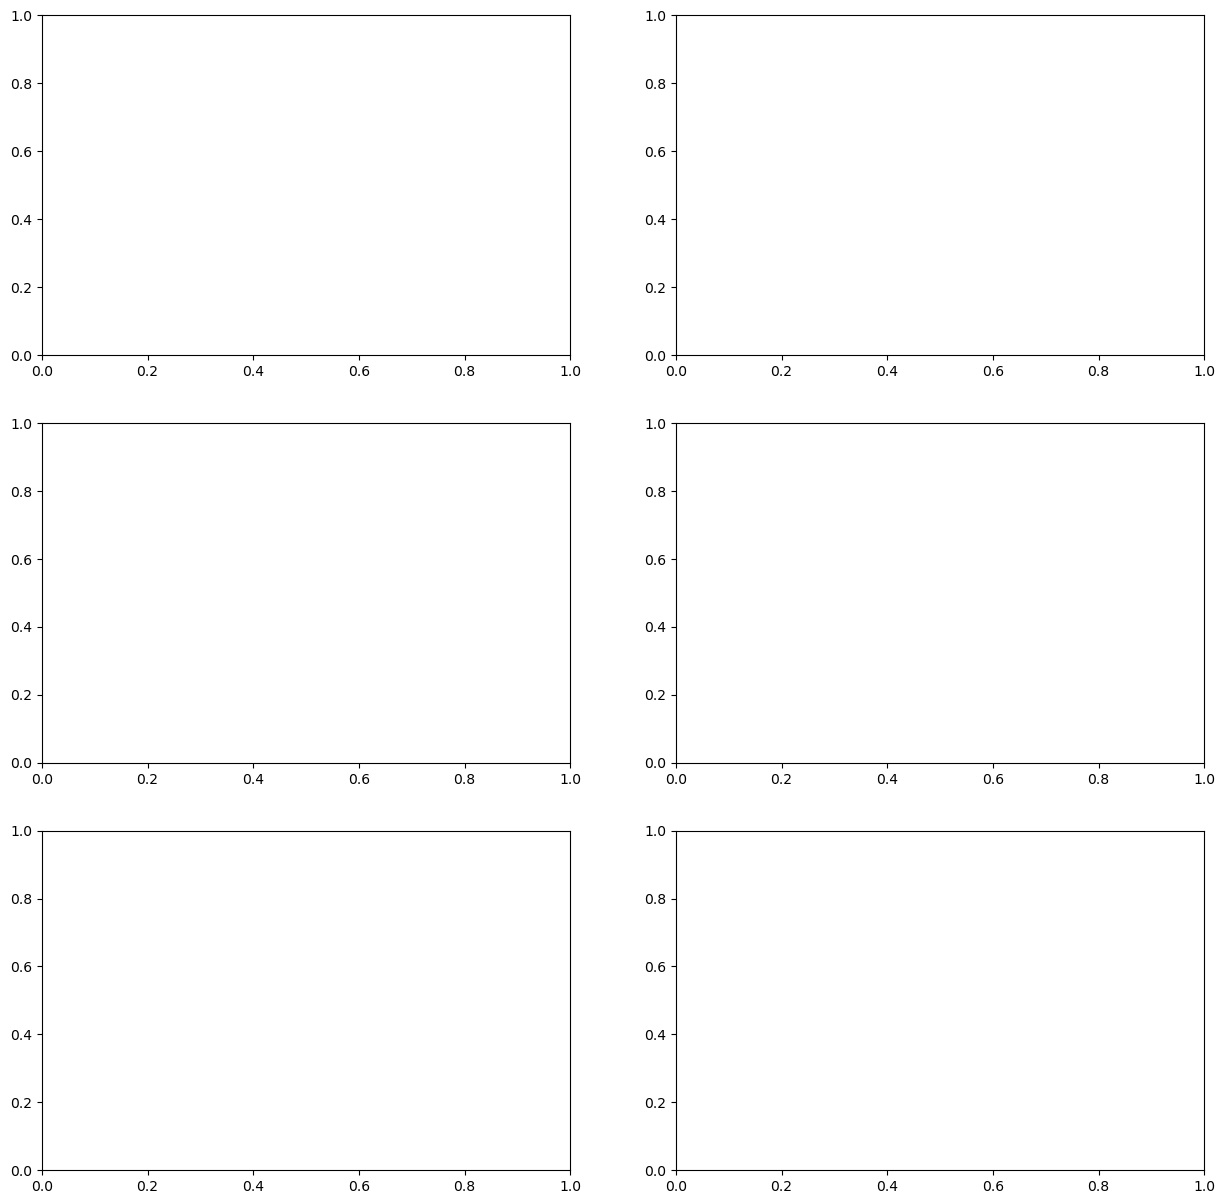

In [4]:
file = xr.open_dataset('../Point_source_detection/data/OCO-2/oco2_GEOS_L3CO2_day_20150101_B10206Ar.nc4')
xco2 = file['XCO2'][0,:,:]
lon = file['lon']
lat = file['lat']


fig, axs = plt.subplots(3, 2, figsize=(15, 15))

regions = {
    'Europe': europe_box,
    'North America': north_america_box,
    'South America': south_america_box,
    'Oceania': oceania_box,
    'Africa': africa_box,
    'Asia': asia_box
}

for ax, (region_name, region_box) in zip(axs.flatten(), regions.items()):
    region_win = sample_within_coordinates(xco2, region_box, lon, lat)
    norm_region_win = normalize_array(region_win)
    sns.kdeplot(np.asarray(norm_region_win).flatten(), ax=ax, fill=True)
    ax.set_title(f'{region_name} Bin Distribution')

plt.tight_layout()
plt.show()

NameError: name 'europe_box' is not defined

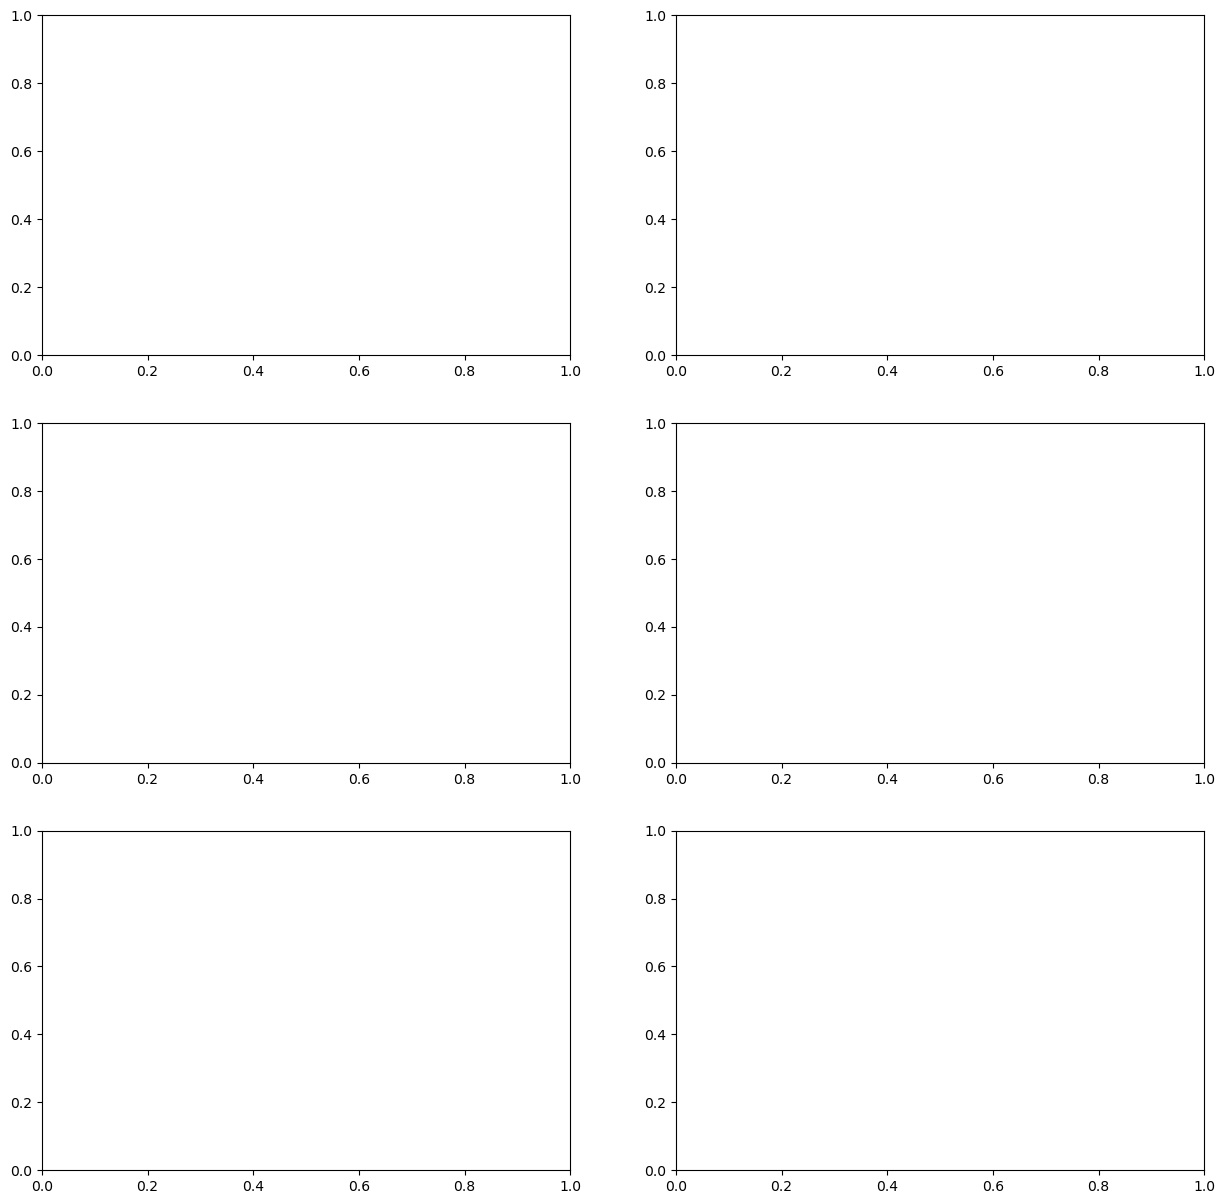

In [ ]:
import json

# file = xr.open_dataset('../Point_source_detection/data/OCO-2/oco2_GEOS_L3CO2_day_20150101_B10206Ar.nc4')
fig, axs = plt.subplots(3, 2, figsize=(15, 15))

regions = {
    'Europe': europe_box,
    'North America': north_america_box,
    'South America': south_america_box,
    'Oceania': oceania_box,
    'Africa': africa_box,
    'Asia': asia_box
}

region_bins = {region: [] for region in regions}

for filename in os.listdir('../Point_source_detection/data/OCO-2/'):
    file = xr.open_dataset('../Point_source_detection/data/OCO-2/'+filename)
    xco2 = file['XCO2'][0,:,:]
    lon = file['lon']
    lat = file['lat']

    for region_name, region_box in regions.items():
        region_win = sample_within_coordinates(xco2, region_box, lon, lat)
        norm_region_win = normalize_array(region_win)
        
        bins_region = bin_values(norm_region_win)
        region_card = np.bincount(bins_region.flatten())
        region_bins[region_name].append(region_card)

for ax, (region_name, bins_list) in zip(axs.flatten(), region_bins.items()):
    ax.boxplot(np.asarray(bins_list), patch_artist=True)
    ax.set_ylim(0, 250)
    ax.set_title(f'{region_name} Bin Distribution')
    ax.legend()

plt.tight_layout()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


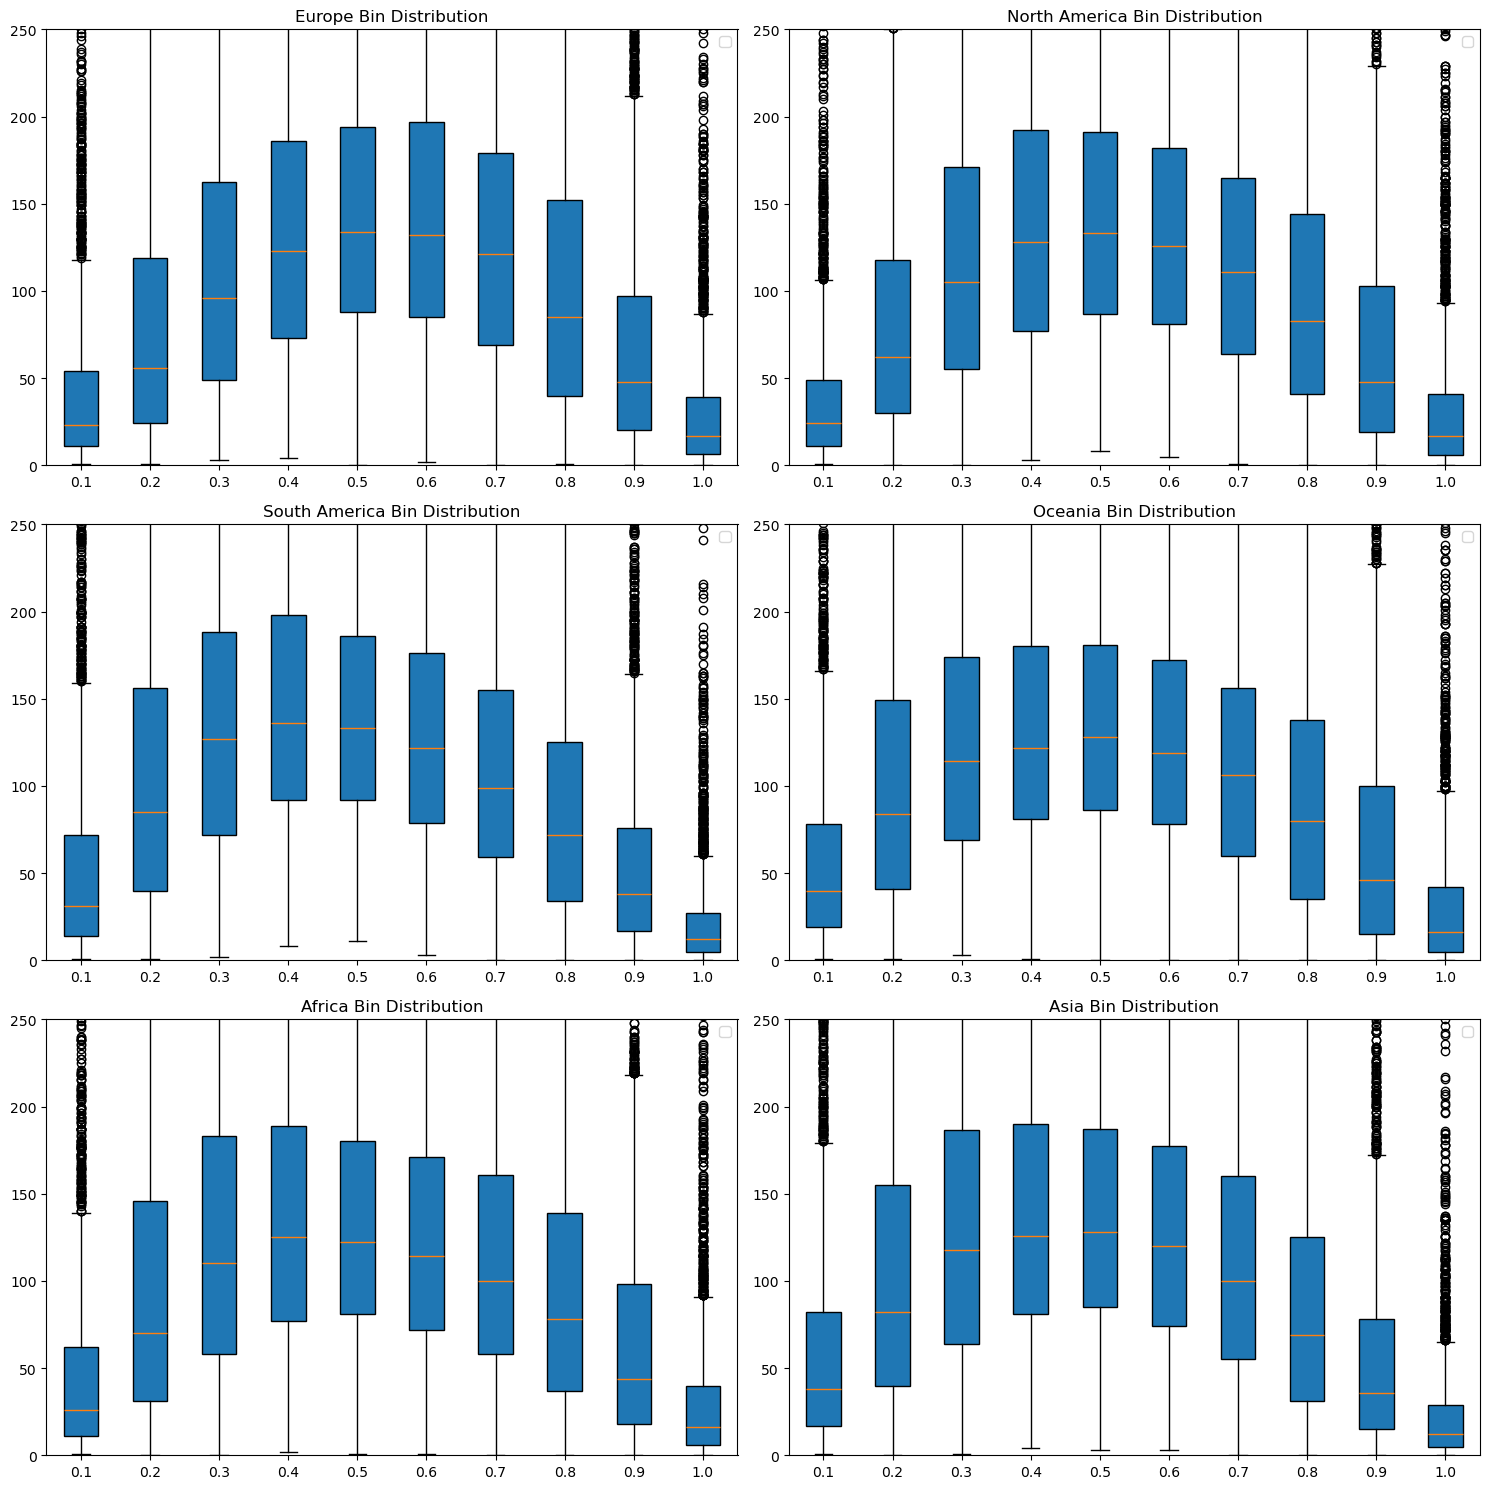

In [12]:
import json

fig, axs = plt.subplots(3, 2, figsize=(15, 15))
regions = {
    'Europe': europe_box,
    'North America': north_america_box,
    'South America': south_america_box,
    'Oceania': oceania_box,
    'Africa': africa_box,
    'Asia': asia_box
}

with open('region_bins.json', 'r') as f:
    region_bins = json.load(f)

for ax, (region_name, bins_list) in zip(axs.flatten(), region_bins.items()):
    bins = np.asarray(bins_list)[:, 1:11]
    ax.boxplot(bins, patch_artist=True)
    ax.set_ylim(0, 250)
    ax.set_xticks(np.arange(1, bins.shape[1] + 1))
    ax.set_xticklabels([f'{i/10}' for i in range(1, bins.shape[1] + 1)])
    ax.set_title(f'{region_name} Bin Distribution')
    ax.legend()

plt.tight_layout()
plt.show()

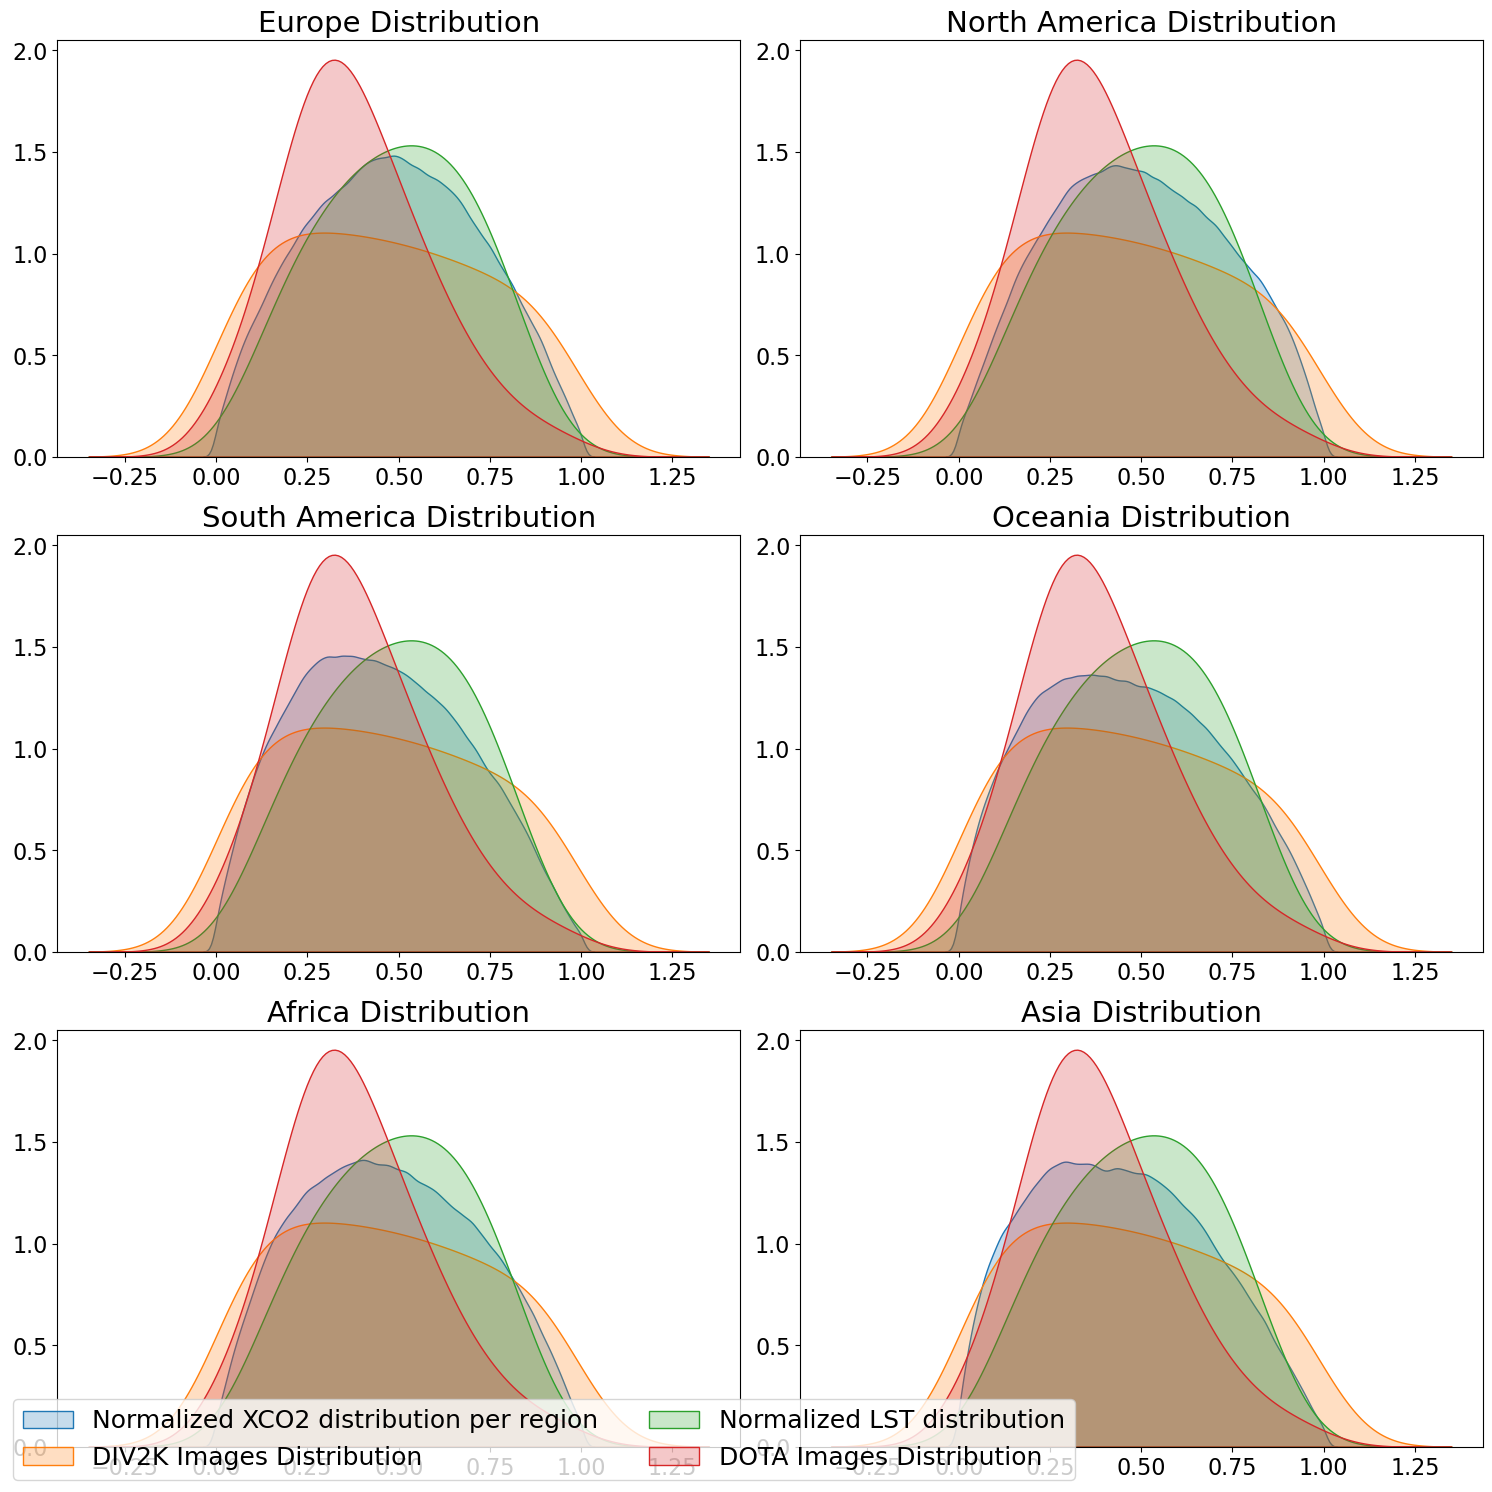

In [ ]:
import json
import seaborn as sns

fig, axs = plt.subplots(3, 2, figsize=(15, 15))
regions = {
    'Europe': europe_box,
    'North America': north_america_box,
    'South America': south_america_box,
    'Oceania': oceania_box,
    'Africa': africa_box,
    'Asia': asia_box
}

with open('region_dist.json', 'r') as f:
    region_dist = json.load(f)

for ax, (region_name, dist) in zip(axs.flatten(), region_dist.items()):
    sns.kdeplot(np.asarray(dist).flatten(), ax=ax, fill=True, legend=False)
    sns.kdeplot(data=div2k_dist, x='value', weights='occurence', ax = ax, fill=True, legend=False)
    sns.kdeplot(data=modis_dist, x='value', weights='occurence', ax = ax, fill=True, legend=False)
    sns.kdeplot(data=dota_dist, x='value', weights='occurence', ax = ax, fill=True, legend=False)
    ax.set_ylabel('')
    ax.set_xlabel('')
    ax.yaxis.set_major_locator(plt.MultipleLocator(0.5))
    ax.tick_params(axis='both', which='major', labelsize=16)
    ax.set_title(f'{region_name} Distribution', family='sans-serif', fontsize=21)
fig.legend(['Normalized XCO2 distribution per region', 'DIV2K Images Distribution', 'Normalized LST distribution', 'DOTA Images Distribution'], loc='lower left', ncol=2, fontsize=18)
plt.tight_layout()
plt.show()

In [ ]:
def gridify_than_normalize(data):
    norm_arrays = []
    # data = np.asarray(data)
    for i in range(0, data.shape[0], 32):
        for j in range(0, data.shape[1], 32):
            sub_array = data[i:i+32, j:j+32]
            if sub_array[~sub_array.mask].size > 0:
                norm_sub_array = normalize_array(sub_array[~sub_array.mask])
                bin_samples = bin_values(norm_sub_array)
                bin_count = np.bincount(bin_samples)
                if len(bin_count) == 12:
                    norm_arrays.append(norm_sub_array)
    return norm_arrays

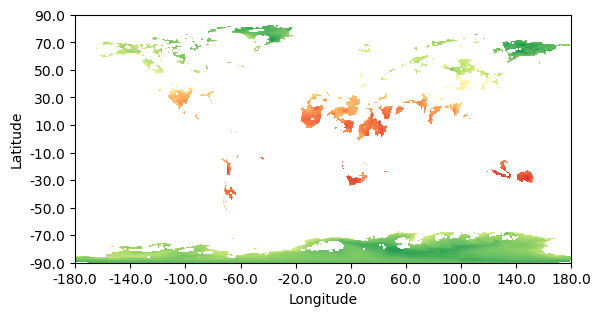

In [ ]:
file = nc.Dataset('../RDS/earthdata/MOD11C1_061-20241106_171429/MOD11C1.A2017032.061.2022024134133.hdf', 'r')
# file = nc.Dataset('/scratch_hive/ar1619/RDS/earthdata/MOD11C1_061-20241106_171429/'+files[j], 'r')
temp_data = file['LST_Day_CMG'][:]
normed_data = gridify_than_normalize(temp_data)
modis_dist = np.concatenate((modis_dist, np.asarray(normed_data).flatten()), axis=None)

In [33]:
def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx

def random_window(array, size=32):
    # print(array.shape)
    x = np.random.randint(0, array.shape[0]-size)
    y = np.random.randint(0, array.shape[1]-size)
    
    return array[x:x+size, y:y+size]

def normalize_array(data):
    vmax = np.amax(data)
    vmin = np.min(data)
    range_data = vmax - vmin
    
    normalized_data = (data - vmin)/range_data
    
    return normalized_data

north_america_box = -135,10,-65.0,60
europe_box = -10, 40, 35, 70
africa_box = -20, -35, 50, 40
asia_box = 40, 0, 150, 70
south_america_box = -80, -50, -40, 10
oceania_box = 115, -40, 155, -10

def sample_within_coordinates(array, coordinates, lon, lat):
    lonW, latS, lonE, latN = coordinates
    lonW = find_nearest(lon, lonW)
    lonE = find_nearest(lon, lonE)
    latS = find_nearest(lat, latS)
    latN = find_nearest(lat, latN)

    if latS > latN:
        return random_window(array[latN:latS, lonW:lonE])
    else:
        return random_window(array[latS:latN, lonW:lonE])

def bin_values(array, bins=11):
    binned_array = np.digitize(array, np.linspace(0, 1, bins))
    
    return binned_array

def gridify_than_normalize(data):
    norm_arrays = []
    # data = np.asarray(data)
    for i in range(0, data.shape[0], 32):
        for j in range(0, data.shape[1], 32):
            sub_array = data[i:i+32, j:j+32]
            if sub_array[~sub_array.mask].size > 0:
                norm_sub_array = normalize_array(sub_array[~sub_array.mask])
                bin_samples = bin_values(norm_sub_array)
                bin_count = np.bincount(bin_samples)
                if len(bin_count) == 12:
                    norm_arrays.append(norm_sub_array)
    return norm_arrays

In [34]:
# modis_dist = []
files = os.listdir('/scratch_hive/ar1619/RDS/earthdata/MOD11C1_061-20241106_171429/')
for i in range(4):
    file = nc.Dataset('/scratch_hive/ar1619/RDS/earthdata/MOD11C1_061-20241106_171429/'+files[i], 'r')
    temp_data = file['LST_Day_CMG'][:]
    normed_data = gridify_than_normalize(temp_data)
    flattened_data = np.concatenate([arr.flatten() for arr in normed_data])
    modis_dist.append(flattened_data)


In [38]:
flat_list = [
    x
    for xs in modis_dist
    for x in xs
]
len(flat_list)

37672184

In [ ]:
latitudes = np.linspace(90, -90, nrows)
longitudes = np.linspace(-180, 180, ncols)
# Sample random 32*32 window between lat [-70, 70] and lon [-180, 180] and only consider values where mask is false
# sample = sample_within_coordinates(temp_data, [-180, -70, 180, 70], longitudes, latitudes)

# Normalize window
norm_sample = normalize_array(sample[~sample.mask])
# Bin values
bin_sample = bin_values(norm_sample[~norm_sample.mask])
np.bincount(bin_sample)
# Plot histogram

array([ 0, 23, 24, 39, 17, 27, 29, 55, 55, 21,  1,  1])

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


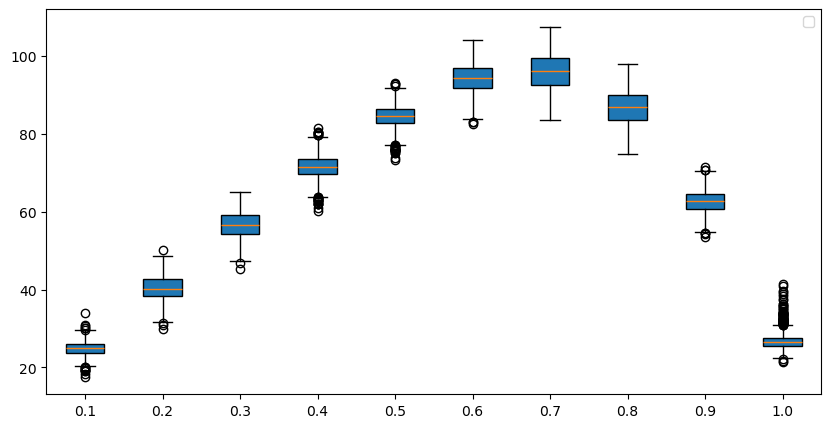

In [9]:
everything = np.load('modis_bins.npy')

plt.figure(figsize=(10, 5))
plt.boxplot(everything, patch_artist=True)
# plt.set_ylim(0, 250)
# plt.set_title('Bin Distribution')
plt.xticks(ticks=np.arange(1, everything.shape[1] + 1), labels=[f'{i/10}' for i in range(1, everything.shape[1] + 1)])
plt.legend()

In [5]:
def bin_values(array, bins=100):
    binned_array = np.digitize(array, np.linspace(0, 1, bins))
    
    return binned_array

def gridify_than_normalize(data):
    norm_arrays = [0 for i in range(100)]
    # data = np.asarray(data)
    for i in range(0, data.shape[0], 32):
        for j in range(0, data.shape[1], 32):
            sub_array = data[i:i+32, j:j+32]
            try:
                normed_sub_array = normalize_array(sub_array)
                bin_samples = bin_values(normed_sub_array).flatten()
                bin_count = np.bincount(bin_samples)
                norm_arrays = [x + y for x, y in zip(norm_arrays, bin_count)]
            except:
                print("Error dividing by zero")
    return norm_arrays

In [21]:
dist = [0 for i in range(101)]
files = os.listdir('/scratch_hive/ar1619/RDS/earthdata/MOD11C1_061-20241106_171429/')
for i in range(4):
    file = nc.Dataset('/scratch_hive/ar1619/RDS/earthdata/MOD11C1_061-20241106_171429/'+files[i], 'r')
    temp_data = file['LST_Day_CMG'][:]
    normed_data = gridify_than_normalize(temp_data)
    dist = [x + y for x, y in zip(dist, normed_data)]



In [39]:
np.save('modis_dist.npy', np.asarray(dist))

<Axes: xlabel='value', ylabel='Density'>

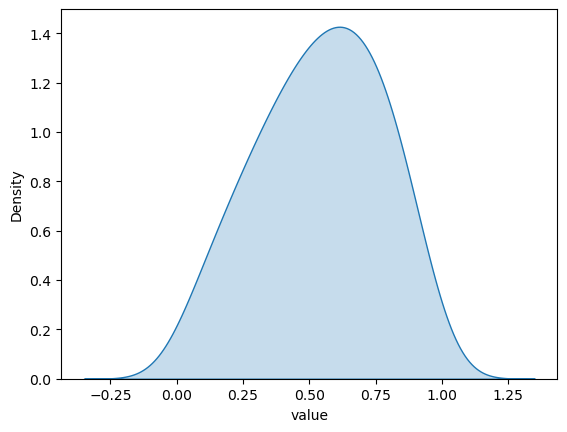

In [37]:
mod_df = pd.DataFrame(data=np.asarray([x, dist]).transpose(), columns=['value', 'occurence'])
sns.kdeplot(data=mod_df, x='value', weights='occurence', fill=True)

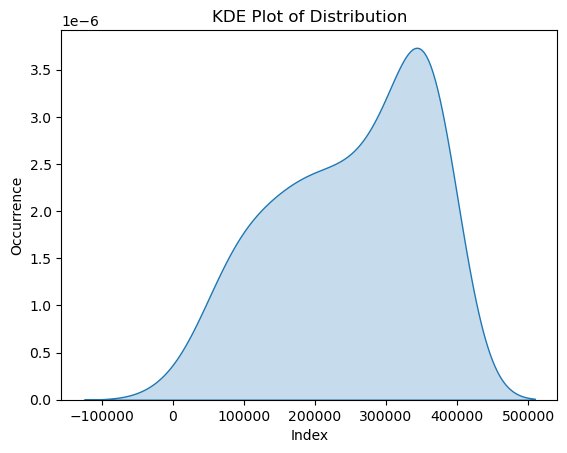

In [17]:
import seaborn as sns
sns.kdeplot(np.asarray(dist).flatten(), fill=True)
plt.xlabel('Index')
plt.ylabel('Occurrence')
plt.title('KDE Plot of Distribution')
plt.show()

## DIV2K data distribution

In [4]:
div2k_dist = np.load('div2k_dist.npy')
x = np.linspace(0, 1, 100)

div2k_dist = pd.DataFrame(np.asarray([x, div2k_dist]).transpose(), columns=['value', 'occurence'])

In [5]:
modis_dist = np.load('modis_dist.npy')

modis_dist = pd.DataFrame(np.asarray([x, modis_dist]).transpose(), columns=['value', 'occurence'])

In [6]:
dota_dist = np.load('dota_dist.npy')
dota_dist = pd.DataFrame(np.asarray([x, dota_dist]).transpose(), columns=['value', 'occurence'])

In [41]:
# oco2_dist = np.load('oco2_dist.npy')
oco2_dist = pd.DataFrame(np.asarray([x, oco2_region_dist]).transpose(), columns=['value', 'occurence'])

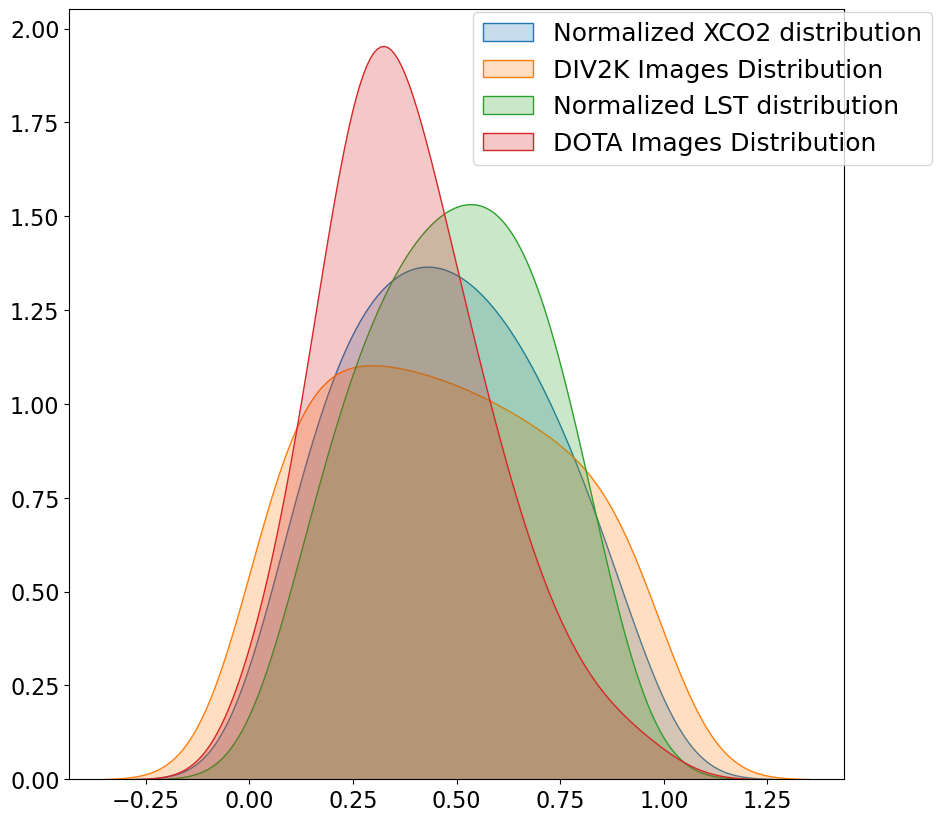

In [46]:
import seaborn as sns
fig, ax = plt.subplots(figsize=(10, 10))
sns.kdeplot(data=oco2_dist, x='value', weights='occurence', fill=True, ax=ax)
sns.kdeplot(data=div2k_dist, x='value', weights='occurence', fill=True, ax=ax)
sns.kdeplot(data=modis_dist, x='value', weights='occurence', fill=True, ax=ax)
sns.kdeplot(data=dota_dist, x='value', weights='occurence', fill=True, ax=ax)
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='both', which='major', labelsize=16)
fig.legend(['Normalized XCO2 distribution', 'DIV2K Images Distribution', 'Normalized LST distribution', 'DOTA Images Distribution'], loc='upper right', ncol=1, fontsize=18, bbox_to_anchor=(1, 0.89))

In [30]:
tips = sns.load_dataset("tips")
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


/tmp/ipykernel_268148/143393343.py:6: RuntimeWarning: invalid value encountered in divide
  normalized_data = (data - vmin)/range_data


<Axes: xlabel='value', ylabel='Density'>

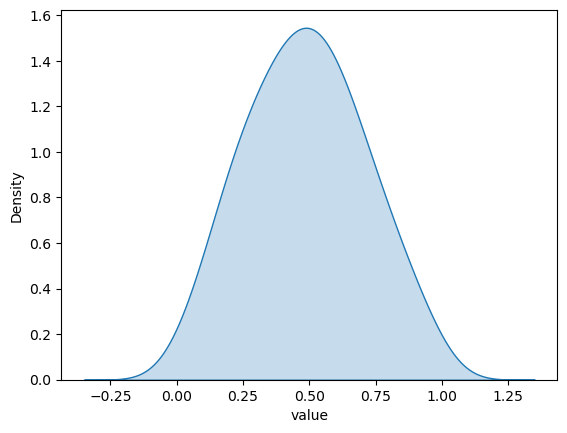

In [9]:
import skimage as ski
from skimage.color import rgb2gray
import seaborn as sns

x = np.linspace(0, 1, 100)
dist = [0 for i in range(101)]
files = os.listdir('../RDS/DOTA/')
for i in range(3):
    file = ski.io.imread('../RDS/DOTA/'+files[i])
    file_gray = np.asarray(rgb2gray(file))
    normed_data = gridify_than_normalize(file_gray)
    dist = [x + y for x, y in zip(dist, normed_data)]

dist_pd = pd.DataFrame(np.asarray([x, dist]).transpose(), columns=['value', 'occurence'])
sns.kdeplot(data=dist_pd, x='value', weights='occurence', fill=True)

In [18]:
import json 
regions = {
    'Europe': europe_box,
    'North America': north_america_box,
    'South America': south_america_box,
    'Oceania': oceania_box,
    'Africa': africa_box,
    'Asia': asia_box
}

with open('region_dist.json', 'r') as f:
    region_dist = json.load(f)

In [39]:
oco2_region_dist = [0 for i in range(100)]
for (region_name, dist) in region_dist.items():
    # bin dist into 101 bins
    binned_dist = np.digitize(dist, np.linspace(0, 1, 100))
    region_card = np.bincount(binned_dist.flatten())
    oco2_region_dist = [x + y for x, y in zip(oco2_region_dist, region_card)]

In [40]:
len(oco2_region_dist)

100